In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
diabetes = load_diabetes()

X_reg = diabetes.data
y_reg = diabetes.target

df_diabetes = pd.DataFrame(X_reg, columns=diabetes.feature_names)
df_diabetes["target"] = y_reg

df_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [4]:
df_diabetes.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [5]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.3,
    random_state=42
)

print("Tamanho do treino:", X_train_reg.shape)
print("Tamanho do teste:", X_test_reg.shape)

Tamanho do treino: (309, 10)
Tamanho do teste: (133, 10)


In [6]:
modelo_linear = LinearRegression()

modelo_linear.fit(X_train_reg, y_train_reg)

y_pred_reg = modelo_linear.predict(X_test_reg)

In [13]:
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 41.91937845679274
RMSE: 53.120156070942706
R²: 0.4772897164322617


In [8]:
comparacao = pd.DataFrame({
    "Valor real": y_test_reg,
    "Valor previsto": y_pred_reg
})

comparacao.head(10)

,Valor real,Valor previsto
0,219.0,138.469700
1,70.0,181.100523
2,202.0,125.344009
3,230.0,292.759773
4,111.0,123.883053
5,84.0,91.898304
6,242.0,257.264631
7,272.0,177.761693
8,94.0,84.985497
9,96.0,109.159610


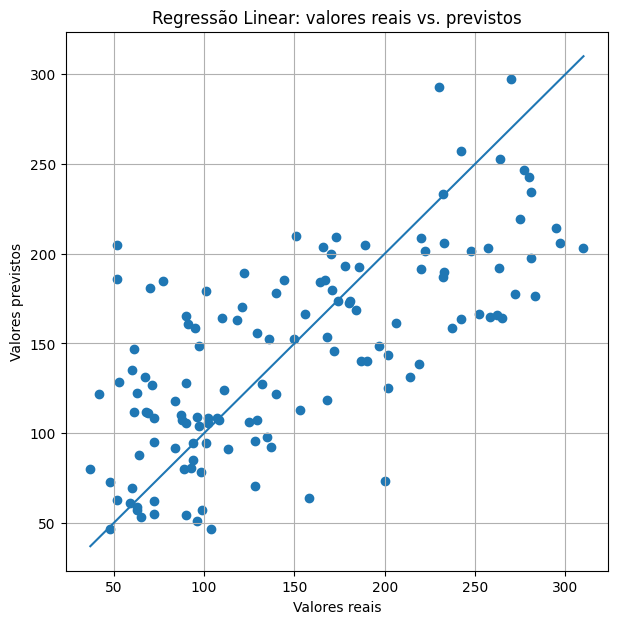

In [9]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test_reg, y_pred_reg)
plt.xlabel("Valores reais")
plt.ylabel("Valores previstos")
plt.title("Regressão Linear: valores reais vs. previstos")

min_val = min(y_test_reg.min(), y_pred_reg.min())
max_val = max(y_test_reg.max(), y_pred_reg.max())

plt.plot([min_val, max_val], [min_val, max_val])
plt.grid(True)
plt.show()

In [10]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

modelo_sgd = make_pipeline(
    StandardScaler(),
    SGDRegressor(
        loss="squared_error",
        learning_rate="constant",
        eta0=0.01,
        max_iter=1000,
        random_state=42
    )
)

modelo_sgd.fit(X_train_reg, y_train_reg)

y_pred_sgd = modelo_sgd.predict(X_test_reg)

In [11]:
mae = mean_absolute_error(y_test_reg, y_pred_sgd)
mse = mean_squared_error(y_test_reg, y_pred_sgd)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_sgd)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 42.08218206936813
RMSE: 53.59991229374468
R²: 0.4678053337045299
